# Lab Assignment 4: Support Vector Machines

In this exercise, we use the Fashion MNIST dataset. We will attempt to separate various pieces of clothing using a Support Vector Machine (SVM). Below, we gather the data and preprocess it for you. As your task, you need to implement an SVM solver, perform finetuning and classification, and finally, show your results using a confusion matrix.

## Library installation
In this lab we will use the `cvxopt` package, [whose documentation can be found here](https://cvxopt.org/userguide/index.html).

We are running version 1.3.2 of `cvxopt`.

In [20]:
!pip install cvxopt

### Package Imports

In [23]:
## =======================================================
## Import Key Packages
## =======================================================
## Standard Fare
import numpy as np
from scipy.io import loadmat

## CVX Opt
import cvxopt
from cvxopt import solvers
from cvxopt import matrix
from sklearn.model_selection import train_test_split
import pandas as pd
from itertools import combinations

solvers.options['show_progress'] = False

## Accessing the Data

In [24]:
training_data = pd.read_csv('./fashion-mnist_train.csv')

y = training_data['label']
X = training_data.drop('label',axis=1)

X = X[:2000]
y = y[:2000]

train_samples, test_samples, train_samples_labels, test_samples_labels = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True)

test_samples_labels=np.squeeze(test_samples_labels)
train_samples_labels=np.squeeze(train_samples_labels)

# Scale pixel features to [0, 1] for numerical stability and better kernel behavior
train_samples = train_samples / 255.0
test_samples = test_samples / 255.0

In [25]:
label_to_title = {0: 'T-shirt/top', 
                  1:'Trouser', 
                  2:'Pullover', 
                  3:'Dress', 
                  4:'Coat', 
                  5:'Sandal',
                  6:'Shirt', 
                  7:'Sneaker', 
                  8:'Bag',
                  9:'Ankle boot'}

In [26]:
print(np.unique(train_samples_labels))
print(np.unique(test_samples_labels))

for i in np.unique(train_samples_labels):
    print(f' There are {sum(train_samples_labels==i)} instances of label #{i}:{label_to_title[i]} in the Train dataset')

[0 1 2 3 4 5 6 7 8 9]
[0 1 2 3 4 5 6 7 8 9]
 There are 197 instances of label #0:T-shirt/top in the Train dataset
 There are 182 instances of label #1:Trouser in the Train dataset
 There are 187 instances of label #2:Pullover in the Train dataset
 There are 190 instances of label #3:Dress in the Train dataset
 There are 200 instances of label #4:Coat in the Train dataset
 There are 160 instances of label #5:Sandal in the Train dataset
 There are 188 instances of label #6:Shirt in the Train dataset
 There are 165 instances of label #7:Sneaker in the Train dataset
 There are 168 instances of label #8:Bag in the Train dataset
 There are 163 instances of label #9:Ankle boot in the Train dataset


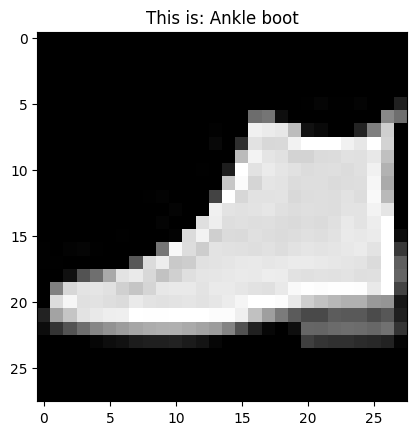

In [27]:
import matplotlib.pyplot as plt
import random

ind = random.randint(0,2000)
plt.imshow(X[ind:ind+1].values.reshape(28,28),cmap='gray')
plt.title(f'This is: {label_to_title[y[ind:ind+1].values[0]]}')
plt.show()

## Task 1:
Develop code for training an SVM for binary classification with nonlinear kernels. You'll need to accomodate non-overlapping class distributions. One way to implement this is to maximize (7.32) subject to (7.33) and (7.34) [in Bishop](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf). It may be helpful to redefine these as matrix operations. Let ${1}\in\mathbb{R}^{N\times 1}$ be the vector whose entries are all 1's. Let $\mathbf{a}\in\mathbb{R}^{N\times 1}$ have entries $a_i$. Let $\mathbf{T}\in\mathbb{R}^{N\times N}$ be a diagonal matrix with $\mathbf{T}_{ii} = t_i$ on the diagonal. Then we can reformulate the objective to be

\begin{equation*}
\begin{aligned}
& \text{maximize}
& & \tilde{L}(\mathbf{a}) = {1}^{\mathrm{T}}\mathbf{a} - \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} \\
& \text{subject to}
& & {1}^{\mathrm{T}} \mathbf{a} \preceq C \\
& & & {1}^{\mathrm{T}} \mathbf{a} \succeq 0 \\
& & & \mathbf{a}^{\mathrm{T}} \mathbf{t} = 0
\end{aligned}
\end{equation*}

The "$\preceq$" symbol here means element-wise comparison. This formulation is very close to what `cvxopt` expects.

Hint (`cvxopt` expects the following form):

\begin{equation*}
\begin{aligned}
& \text{minimize}
& & \tilde{L}(\mathbf{a}) = \frac{1}{2} \mathbf{a}^{\mathrm{T}} \mathbf{T}\mathbf{K} \mathbf{T}\mathbf{a} - {1}^{\mathrm{T}}\mathbf{a} \\
& \text{subject to}
& & G \mathbf{a} \preceq h \\
& & & {\mathbf{t}}^{\mathrm{T}}\mathbf{a} = 0
\end{aligned}
\end{equation*}

where $G$ is an $N\times N$ identity matrix ontop of $-1$ times an $N\times N$ identity matrix and $h \in\mathbb{R}^{2N}$ where the first $N$ entries are $C$ and the second $N$ enties are $0$.

## Task 2:
Develop code to predict the $\{-1,+1\}$ class for new data. To use the predictive model (7.13) you need to determine $b$, which can be done with (7.37). 

We have provided some starter code in the cells below

In [ ]:
def nonlinear_kernel(X, y):
  """
  Implement a nonlinear kernel function. Function parameters will vary depending on kernel function.
  Feel free to implement either 'rbf', 'poly' or 'sigmoid'
  WARNING: 'rbf' can be quite slow and there exist some approximation methods
  Parameters
  ----------
  X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
    Training vectors, where n_samples is the number of samples and n_features 
    is the number of features. For kernel=”precomputed”, the expected shape 
    of X is (n_samples, n_samples).

  y : array-like of shape (n_samples,)
    Target values (class labels in classification, real numbers in regression).
    
  """
  # Polynomial kernel: K(x, x') = (x^T x' + c)^d
  # Parameters: d = degree, c = constant term
  d = 2
  c = 1

  # Ensure we have numpy arrays for matrix operations
  X = np.asarray(X)
  y = np.asarray(y)

  # Gram matrix: inner products between all pairs (row of X, row of y)
  # Shape is (n_samples_X, n_samples_y)
  linear_part = np.dot(X, y.T)

  # Apply polynomial kernel formula
  K = (linear_part + c) ** d

  return K

In [29]:
class SVM(object):

  def __init__(self, kernel=nonlinear_kernel, C=1.0):
    """
    Initialize SVM

    Parameters
    ----------
    kernel : callable
      Specifies the kernel type to be used in the algorithm. It is used to pre-compute 
      the kernel matrix from data matrices; that matrix should be an array 
      of shape (n_samples, n_samples).
    C : float, default=1.0
      Regularization parameter. The strength of the regularization is inversely
      proportional to C. Must be strictly positive. The penalty is a squared l2
      penalty.
    """
    self.kernel = kernel
    self.C = C

    # Initialize attributes used by fit() and predict() so the object is valid before fit
    self.b = 0
    self.X = None
    self.y = None
    self.support_vectors = None
    self.support_vector_labels = None
    self.alphas = None

  def fit(self, X, y):
    """
    Fit the SVM model according to the given training data.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples, n_samples)
      Training vectors, where n_samples is the number of samples and n_features 
      is the number of features. For kernel=”precomputed”, the expected shape 
      of X is (n_samples, n_samples).

    y : array-like of shape (n_samples,)
      Target values (class labels in classification, real numbers in regression).

    Returns
    -------
    self : object
      Fitted estimator.
    """
    # Hint:
    # 1. Define Quadratic Programming (QP) parameters. Given a QP optimization 
    #    problem in standard form, cvxopt is looking for P, q, G, h, A, and b
    #    (https://cvxopt.org/userguide/coneprog.html#quadratic-cone-programs).
    # 2. Construct the QP, invoke solver (use cvxopt.solvers.qp to maximize the Lagrange (7.32))
    # 3. Extract optimal value and solution. cvxopt.solvers.qp(P, q, G, h, A, b)["x"]
    #    are the Lagrange multipliers.

    # 1. Define QP parameters

    # Convert to numpy so X[sv] and X[use] index rows; DataFrame would index columns
    X = np.asarray(X)
    y = np.asarray(y).flatten()
    self.X = X
    self.y = y
    n_samples, n_features = X.shape

    k = self.kernel(X, X)

    P = np.outer(y, y) * k
    q = np.ones(n_samples) * -1

    G = np.vstack((-np.eye(n_samples), np.eye(n_samples)))
    h = np.hstack((np.zeros(n_samples), np.ones(n_samples) * self.C))

    A = y.reshape(1, -1)
    b = np.array([0.0])

    P_ = matrix(P, tc='d')
    q_ = matrix(q, tc='d')
    G_ = matrix(G, tc='d')
    h_ = matrix(h, tc='d')
    A_ = matrix(A, tc='d')
    b_ = matrix(b, tc='d')

    # 2. Invoke QP solver
    lagrange = solvers.qp(P_, q_, G_, h_, A_, b_)

    # 3. Extract optimal value
    alphas = np.array(lagrange['x']).ravel()

    # 4. Get bias from support vectors by 7.37
    tau = 1e-5
    sv = np.where(alphas > tau)[0]
    self.support_vectors = X[sv]
    self.support_vector_labels = y[sv].flatten()
    self.alphas = alphas[sv]

    # If no support vectors, bias is 0; otherwise compute from margin SVs (Bishop 7.37)
    if len(sv) == 0:
        self.b = 0.0
        return self

    margin = np.where((alphas > tau) & (alphas < self.C - tau))[0]
    use = margin if len(margin) > 0 else sv
    K_s = self.kernel(self.support_vectors, X[use])

    b_vals = y[use] - (self.alphas * self.support_vector_labels) @ K_s
    self.b = np.mean(b_vals) if len(b_vals) > 0 else 0.0

    return self

  def predict(self, X):
    """
    Perform classification on samples in X.

    For an one-class model, +1 or -1 is returned.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features) or (n_samples_test, n_samples_train)

    Returns
    -------
    y_pred : ndarray of shape (n_samples,)
      Class labels for samples in X.
    """

    def decision_function(X):
        Ktest = self.kernel(self.support_vectors, X)
        return (self.alphas * self.support_vector_labels) @ Ktest + self.b

    decision_values = decision_function(X)

    return np.sign(decision_values).astype(int)

  def score(self, X, y):
    """
    Return the mean accuracy on the given test data and labels. 
    
    In multi-label classification, this is the subset accuracy which is a harsh 
    metric since you require for each sample that each label set be correctly 
    predicted.

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
      Test samples.
    y : array-like of shape (n_samples,) or (n_samples, n_outputs)
      True labels for X.

    Return
    ------
    score : float
      Mean accuracy of self.predict(X)
    """

    y_hat = self.predict(X).ravel()
    y = np.asarray(y).flatten()
    res = np.sum(y_hat == y)/(y.size)
    return res

## Task 3:
Using your implementation, compare multiclass classification performance of two different voting schemes:
* one vs. rest
* one vs. one

In [ ]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

class OneVsRestClassifier():
    def __init__(self, num_labels, C = 1.0):
        '''
            num_labels: number of labels.
            C: regularization parameter for SVM.
        '''
        self.classifiers = [] # a list of classifiers corresponding to labels
        self.C = C
        self.num_labels = num_labels
        
    def convert_labels(self, one_label, samples_labels):
        '''
            This function converts ~target_label/target_label to -1/1.
            Args:
            one_label: the target label we want to different with the remaining label.
            samples_labels: the original labels.
        '''
        mask = (samples_labels == one_label).astype(bool)
        samples_labels[mask] = 1
        samples_labels[~mask] = -1
        samples_labels = np.asarray(samples_labels).flatten()
        return samples_labels
        
    def fit(self, train_samples, train_samples_labels):
        '''
            Fitting function for OVR classifier.
        '''
        for i in range(self.num_labels):
            new_train_labels = self.convert_labels(i, train_samples_labels.copy())
            svm = SVM(C=self.C)
            svm.fit(train_samples, new_train_labels)
            self.classifiers.append(svm)
        
        
    def predict(self, test_samples):
        '''
            Predict test samples' labels. This function should return labels from 0-9 for each sample.
        '''
        # Insert your code here
        # Use raw decision values so argmax picks the class with highest confidence
        test_samples = np.asarray(test_samples)
        S = []
        for k in range(self.num_labels):
            clf = self.classifiers[k]
            Ktest = clf.kernel(clf.support_vectors, test_samples)
            decision = (clf.alphas * clf.support_vector_labels) @ Ktest + clf.b
            S.append(decision)
        S = np.vstack(S)
        return S.argmax(axis=0)
        
    def score(self, test_samples, test_samples_labels):
        '''
            Return the accuracy of the OVR classifier.
        '''
        for i in range(self.num_labels):
            test_new_labels = self.convert_labels(i, test_samples_labels.copy())
            print(f"% correct for label {i}: ", self.classifiers[i].score(test_samples, test_new_labels))
        results = self.predict(test_samples)
        res = np.sum(results == test_samples_labels.squeeze())/test_samples.shape[0]
        print("One vs Rest Performance on Test Set:", res)
        return res


# Try wtih OVR
# Use high C so the SVM fits the data instead of predicting all -1
ovr_classifier = OneVsRestClassifier(10, C=10.0)
ovr_classifier.fit(train_samples, train_samples_labels)
ovr_classifier.score(test_samples, test_samples_labels)

% correct for label 0:  0.96
% correct for label 1:  0.995
% correct for label 2:  0.925
% correct for label 3:  0.955
% correct for label 4:  0.94
% correct for label 5:  0.98
% correct for label 6:  0.91
% correct for label 7:  0.98
% correct for label 8:  0.985
% correct for label 9:  0.965
One vs Rest Performance on Test Set: 0.83


np.float64(0.83)

In [ ]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

class OneVsOneClassifier():
    def __init__(self, num_labels, C = 1.0):
        '''
            num_labels: number of labels.
            C: regularization parameter for SVM.
        '''
        self.num_labels = num_labels
        self.classifiers = {} 
        self.C = C


        self.pairs = list(combinations(range(self.num_labels), 2))

    
    def split_dataset(self, i_label, j_label, train_samples, train_samples_labels):
        '''
            Filter the samples to the target i and j samples only. Remember to assign -1/1 labels as well.
            Args:
                i_label: the mask corresponding to label i.
                j_label: the mask corresponding to label j.
                train_samples: original samples for training.
                tran_samples_labels: original labels for training.
        '''
        train_samples_labels = np.asarray(train_samples_labels).flatten()
        mask = (train_samples_labels == i_label) | (train_samples_labels == j_label)
        samples = np.asarray(train_samples)[mask]
        orig_labels = train_samples_labels[mask]
        labels = np.where(orig_labels == i_label, 1, -1)
        return samples, labels


    
    def fit(self, train_samples, train_samples_labels):
        '''
            Fitting function for OVO classifier.
        '''

        for (i, j) in self.pairs:
            new_train_samples, new_train_labels = self.split_dataset(i, j, train_samples, train_samples_labels)
            svm = SVM(C=self.C)
            svm.fit(new_train_samples, new_train_labels)
            self.classifiers[(i, j)] = svm
    
    def predict(self, test_samples):
        '''
            Predict test samples' labels. This function should return labels from 0-9 for each sample.
        '''
        votes = np.zeros ((len(test_samples), 10) , dtype =int)
        for (i, j), clf in self.classifiers.items():
            pred_ij = clf.predict(test_samples)
            votes[:, i] += (pred_ij == 1).astype(int)
            votes[:, j] += (pred_ij == -1).astype(int)
        return votes.argmax(axis=1)

    
    def score(self, test_samples, test_samples_labels):
        '''
            Return the accuracy of the OVR classifier.
        '''
        for i in range(self.num_labels):
            for j in range(i + 1, self.num_labels):
                new_test_samples, new_test_samples_labels = self.split_dataset(i, j, test_samples, test_samples_labels)
                print(f"% correct for sub-dataset {(i, j)}", self.classifiers[(i, j)].score(new_test_samples, new_test_samples_labels))
        results = self.predict(test_samples)
        res = np.sum(results == test_samples_labels.squeeze())/test_samples.shape[0]
        print("One vs One Performance on Test Set:", res)
        return res

# Try with OVO
ovo_classifier = OneVsOneClassifier(10)
ovo_classifier.fit(train_samples, train_samples_labels)
ovo_classifier.score(test_samples, test_samples_labels)

% correct for sub-dataset (0, 1) 1.0
% correct for sub-dataset (0, 2) 0.975
% correct for sub-dataset (0, 3) 0.8421052631578947
% correct for sub-dataset (0, 4) 1.0
% correct for sub-dataset (0, 5) 1.0
% correct for sub-dataset (0, 6) 0.9444444444444444
% correct for sub-dataset (0, 7) 1.0
% correct for sub-dataset (0, 8) 1.0
% correct for sub-dataset (0, 9) 1.0
% correct for sub-dataset (1, 2) 1.0
% correct for sub-dataset (1, 3) 0.9393939393939394
% correct for sub-dataset (1, 4) 0.9666666666666667
% correct for sub-dataset (1, 5) 1.0
% correct for sub-dataset (1, 6) 1.0
% correct for sub-dataset (1, 7) 1.0
% correct for sub-dataset (1, 8) 1.0
% correct for sub-dataset (1, 9) 1.0
% correct for sub-dataset (2, 3) 0.9545454545454546
% correct for sub-dataset (2, 4) 0.8780487804878049
% correct for sub-dataset (2, 5) 1.0
% correct for sub-dataset (2, 6) 0.7619047619047619
% correct for sub-dataset (2, 7) 1.0
% correct for sub-dataset (2, 8) 0.9743589743589743
% correct for sub-dataset (

np.float64(0.8)

## Task 4:
The parameter $C>0$ controls the tradeoff between the size of the margin and the slack variable penalty. It is analogous to the inverse of a regularization coefficient. Include in your report a brief discussion of how you found an appropriate value.

Hint: Try using np.linspace or logspace for hyperparameter tuning

Hint: I recommend **high** C 

In [32]:
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.

Cs = np.logspace(-1, 3, num=10)

best, best_acc = None, -1.0

for C in Cs:
    ovo_classifier = OneVsOneClassifier(10, C=C)
    ovo_classifier.fit(train_samples, train_samples_labels)
    acc = ovo_classifier.score(test_samples, test_samples_labels)
    if acc > best_acc:
        best_acc = acc
        best = C


best_ovr, best_acc_ovr = None, -1.0

for C in Cs:
    ovr_classifier = OneVsRestClassifier(10, C=C)
    ovr_classifier.fit(train_samples, train_samples_labels)
    acc = ovr_classifier.score(test_samples, test_samples_labels)
    if acc > best_acc_ovr:
        best_acc_ovr = acc
        best_ovr = C

print("Best for OVO:", best, "Val acc:", best_acc)
print("Best for OVR:", best_ovr, "Val acc:", best_acc_ovr)
# Retrain with best C so Task 5 confusion matrices use the best-tuned classifiers
ovo_classifier = OneVsOneClassifier(10, C=best)
ovo_classifier.fit(train_samples, train_samples_labels)
ovr_classifier = OneVsRestClassifier(10, C=best_ovr)
ovr_classifier.fit(train_samples, train_samples_labels)


% correct for sub-dataset (0, 1) 1.0
% correct for sub-dataset (0, 2) 0.975
% correct for sub-dataset (0, 3) 0.8421052631578947
% correct for sub-dataset (0, 4) 1.0
% correct for sub-dataset (0, 5) 1.0
% correct for sub-dataset (0, 6) 0.9444444444444444
% correct for sub-dataset (0, 7) 1.0
% correct for sub-dataset (0, 8) 1.0
% correct for sub-dataset (0, 9) 1.0
% correct for sub-dataset (1, 2) 1.0
% correct for sub-dataset (1, 3) 0.9393939393939394
% correct for sub-dataset (1, 4) 0.9666666666666667
% correct for sub-dataset (1, 5) 1.0
% correct for sub-dataset (1, 6) 1.0
% correct for sub-dataset (1, 7) 1.0
% correct for sub-dataset (1, 8) 1.0
% correct for sub-dataset (1, 9) 1.0
% correct for sub-dataset (2, 3) 0.9545454545454546
% correct for sub-dataset (2, 4) 0.8780487804878049
% correct for sub-dataset (2, 5) 1.0
% correct for sub-dataset (2, 6) 0.7619047619047619
% correct for sub-dataset (2, 7) 1.0
% correct for sub-dataset (2, 8) 0.9743589743589743
% correct for sub-dataset (

## Task 5:
In addition to calculating percent accuracy, generate multiclass [confusion matrices](https://en.wikipedia.org/wiki/confusion_matrix) as part of your analysis.

In [ ]:
# Simple confusion matrix computation
## Write and Run Your Own Code Here
## Please Add Additional Cells as Needed.
# Use your trained classifier 

predictions = ovr_classifier.predict(test_samples)
# OVO predictions for second confusion matrix 
predictions_ovo = ovo_classifier.predict(test_samples) 


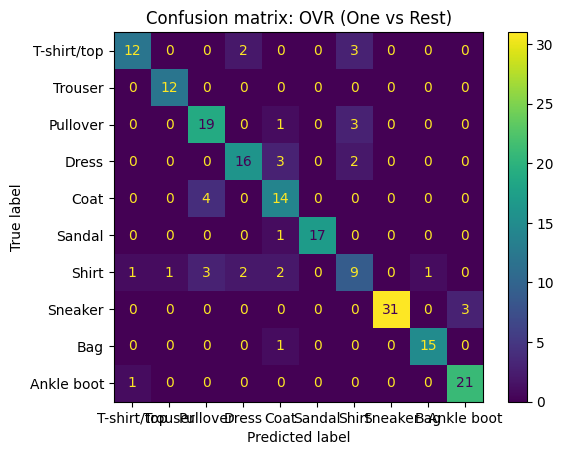

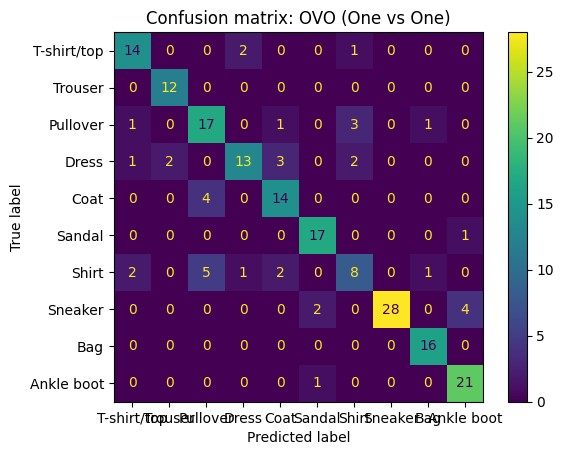

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Class names for readable axis labels (row = true, col = predicted)
class_labels = np.unique(test_samples_labels)
display_labels = [label_to_title[i] for i in class_labels]
# Confusion matrix for OVR classifier
cm = confusion_matrix(test_samples_labels, predictions, labels=class_labels)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
import matplotlib.pyplot as plt
cm_display.plot()
plt.title("Confusion matrix: OVR (One vs Rest)")
plt.show()
# Confusion matrix for OVO classifier
cm_ovo = confusion_matrix(test_samples_labels, predictions_ovo, labels=class_labels)
cm_ovo_display = ConfusionMatrixDisplay(confusion_matrix=cm_ovo, display_labels=display_labels)
cm_ovo_display.plot()
plt.title("Confusion matrix: OVO (One vs One)")
plt.show()

### What to Submit
Please submit the following:

1. A Jupyter notebook that contains your completed notebook, where the output of each cell is clearly displayed.

2. A brief write-up that answers the 5 questions posed in this lab and justifies your model. Ensure that any figures you create are accessible and easy to understand.